In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, r2_score
from sklearn.tree import DecisionTreeClassifier

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train, y_train)
rf_acc = r2_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy: {rf_acc}")

Random Forest Accuracy: 1.0


In [ ]:
base_tree = DecisionTreeClassifier(max_depth=1)
ada = AdaBoostClassifier(estimator=base_tree,  n_estimators=10,  learning_rate=0.1, random_state=42
)
ada.fit(X_train, y_train)
ada_acc = r2_score(y_test, ada.predict(X_test))
print(f"AdaBoost Accuracy: {ada_acc}")

AdaBoost Accuracy: 0.967948717948718


In [ ]:
ensemble = VotingClassifier(estimators=[('rf', rf), ('ada', ada)], voting='soft')
ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('rf', RandomForestClassifier(n_estimators=10)),
                             ('ada',
                              AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                                 learning_rate=0.1,
                                                 n_estimators=10,
                                                 random_state=42))],
                 voting='soft')

In [ ]:
ens_acc = r2_score(y_test, ensemble.predict(X_test))
print(f"Ensemble Accuracy: {ens_acc}")

Ensemble Accuracy: 1.0


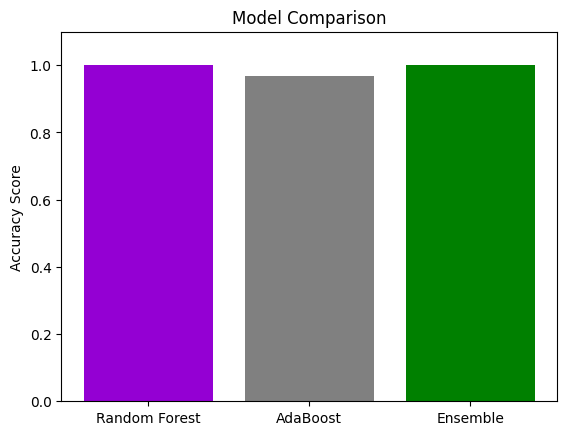

In [ ]:
models = ['Random Forest', 'AdaBoost', 'Ensemble']
scores = [rf_acc, ada_acc, ens_acc]

plt.bar(models, scores, color=['darkviolet', 'gray', 'green'])
plt.ylabel('Accuracy Score')
plt.title('Model Comparison')
plt.ylim(0, 1.1)
plt.show()

In [ ]:
rf_importance = rf.feature_importances_
ada_importance = ada.feature_importances_
print(rf_importance)
print(ada_importance)
ensemble_importance = (rf_importance + ada_importance) / 2

[0.10781217 0.02627934 0.39052547 0.47538302]
[0.         0.         0.60183206 0.39816794]


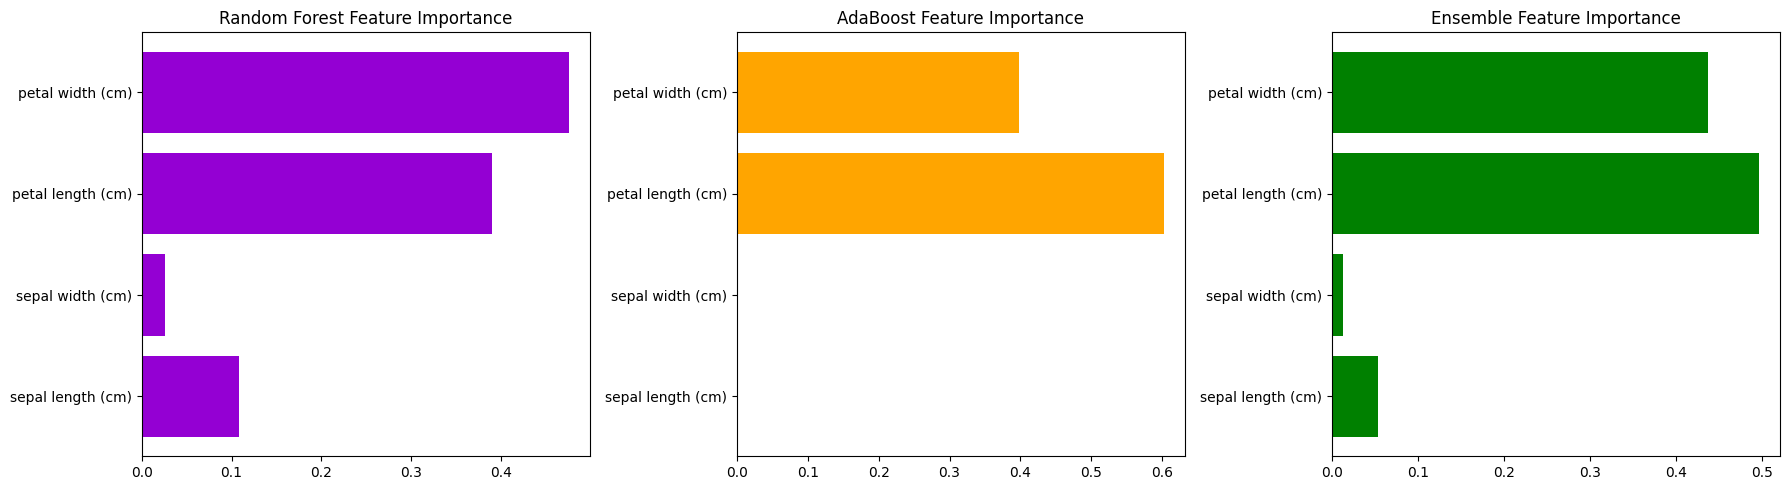

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(feature_names, rf_importance, color='darkviolet')
axes[0].set_title("Random Forest Feature Importance")

axes[1].barh(feature_names, ada_importance, color='orange')
axes[1].set_title("AdaBoost Feature Importance")

axes[2].barh(feature_names, ensemble_importance, color='green')
axes[2].set_title("Ensemble Feature Importance")

plt.tight_layout()
plt.show()